# Neural Style Transfer

---

## 1. Introduction to Neural Style Transfer {#introduction}

**Neural Style Transfer** is a fascinating application of deep learning that allows us to **paint one image in the style of another**. Introduced by Gatys et al. in 2015, this technique has revolutionized digital art and image processing.

### The Magic Formula

Neural Style Transfer takes three inputs:
- **Content Image**: What you want to paint (e.g., a photograph of a landscape)
- **Style Image**: How you want it painted (e.g., Van Gogh's Starry Night)
- **Output**: Your photograph painted in Van Gogh's style!

### Real-World Examples

Imagine transforming:
- Your selfie into a Picasso painting
- A cityscape into an impressionist masterpiece
- A nature photo into an abstract art piece

The key insight: **CNNs naturally separate content from style** at different layers, allowing us to manipulate them independently.


In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
from typing import Dict, List, Tuple, Optional, Union
import requests
from io import BytesIO

# Set device and random seed for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

# Image preprocessing
def preprocess_image(image_path: str, target_size: Tuple[int, int] = (512, 512)) -> torch.Tensor:
    """
    Preprocess an image for neural style transfer.

    Args:
        image_path (str): Path to the image file
        target_size (Tuple[int, int], optional): Target image size. Defaults to (512, 512).

    Returns:
        torch.Tensor: Preprocessed image tensor
    """
    transform = transforms.Compose([
        transforms.Resize(target_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    if image_path.startswith('http'):
        response = requests.get(image_path)
        image = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        image = Image.open(image_path).convert('RGB')

    return transform(image).unsqueeze(0)

def deprocess_image(tensor: torch.Tensor) -> np.ndarray:
    """
    Convert a tensor back to a displayable image.

    Args:
        tensor (torch.Tensor): Image tensor to deprocess

    Returns:
        np.ndarray: Deprocessed image as numpy array
    """
    # Denormalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    tensor = tensor.squeeze(0) * std + mean
    tensor = torch.clamp(tensor, 0, 1)

    return tensor.permute(1, 2, 0).cpu().numpy()

print("Preprocessing functions defined successfully")


Preprocessing functions defined successfully


## 2. The Core Concept

### How Neural Style Transfer Works

The breakthrough insight of Gatys et al. was that **different layers of a CNN capture different types of information**:

- **Early Layers** (conv1, conv2): Capture low-level features like edges, textures, colors
- **Middle Layers** (conv3, conv4): Capture mid-level patterns and structures  
- **Late Layers** (conv5): Capture high-level content like objects and scenes

### The Two-Part Strategy

1. **Content Representation**: Use features from **deeper layers** to preserve the structure and objects
2. **Style Representation**: Use features from **multiple layers** to capture texture patterns and artistic style

### Mathematical Foundation

The total loss combines three components:

```
Total Loss = α × Content Loss + β × Style Loss + γ × Total Variation Loss
```

Where:
- **α, β, γ** are weighting parameters
- **Content Loss**: Measures how well content is preserved
- **Style Loss**: Measures how well style is transferred
- **Total Variation Loss**: Encourages spatial smoothness (optional)

### The Optimization Process

Unlike training a network, we **optimize the pixels of the output image** directly:

1. Start with a random noise image (or copy of content image)
2. Extract features from content and style images using pre-trained VGG
3. Compute losses by comparing generated image features to target features
4. Use gradient descent to update the **pixel values** of the generated image
5. Repeat until convergence


## 2.5. Deep Dive: Understanding Gram Matrices {#gram-matrices}

### What is a Gram Matrix?

The **Gram matrix** is the mathematical heart of neural style transfer. Named after Jørgen Pedersen Gram, it's a fundamental concept that allows us to capture and represent the "style" of an image in a way that's independent of spatial location.

### Mathematical Definition

For a feature map **F** with dimensions `(channels, height, width)`, the Gram matrix **G** is defined as:

```
G_ij = Σ_k F_ik * F_jk
```

Where:
- **G_ij** is the correlation between feature channel **i** and channel **j**
- **F_ik** is the activation of channel **i** at spatial location **k**
- The sum is over all spatial locations **k**

In matrix form: **G = F × F^T** (after reshaping F appropriately)

### Why Gram Matrices Capture Style

#### 1. **Spatial Independence**
The Gram matrix deliberately **ignores spatial information**. By computing correlations between feature channels across all spatial locations, it captures:
- **What textures appear together** (high correlation)
- **What patterns co-occur** regardless of where they are
- **Global style characteristics** rather than specific object locations

#### 2. **Texture Representation**
Different feature channels in CNNs respond to different visual patterns:
- **Channel A**: Might detect horizontal lines
- **Channel B**: Might detect diagonal textures  
- **Channel C**: Might detect circular patterns

The Gram matrix tells us:
- **G_AB**: How often horizontal and diagonal patterns appear together
- **G_AC**: How often horizontal and circular patterns co-occur
- **G_BC**: How often diagonal and circular patterns are correlated

#### 3. **Style vs Content Separation**
- **Content**: Represented by the actual feature activations (what and where)
- **Style**: Represented by feature correlations (how patterns relate)

### Intuitive Understanding

Think of the Gram matrix as a **"style fingerprint"**:

1. **Impressionist Painting**: High correlations between:
   - Brush stroke patterns and color blobs
   - Soft edges and bright colors
   - Organic shapes and flowing textures

2. **Gothic Architecture**: High correlations between:
   - Vertical lines and sharp angles
   - Dark tones and geometric patterns
   - Repetitive structures and ornate details

3. **Van Gogh's Style**: High correlations between:
   - Swirling patterns and bold colors
   - Thick brush strokes and dynamic textures
   - Contrasting colors and energetic movements

### Mathematical Properties

#### **Symmetry**
```
G_ij = G_ji
```
The Gram matrix is always symmetric because correlation is bidirectional.

#### **Positive Semi-definite**
```
x^T G x ≥ 0 for all vectors x
```
All eigenvalues are non-negative, making it mathematically well-behaved.

#### **Scale Invariance**
The normalized Gram matrix is invariant to uniform scaling of feature magnitudes.

#### **Permutation Invariance**
Reordering spatial locations doesn't change the Gram matrix.

### Why This Works for Style Transfer

#### **1. Translation Invariance**
Style characteristics should be the same regardless of where they appear in the image. A Van Gogh swirl pattern should be recognizable whether it's in the sky or water.

#### **2. Statistical Texture Modeling**
The Gram matrix models the **second-order statistics** of features:
- **First-order**: Individual feature means (captured by content loss)
- **Second-order**: Feature correlations (captured by style loss via Gram matrix)

#### **3. Multi-scale Capture**
Using Gram matrices from multiple CNN layers captures style at different scales:
- **Early layers**: Fine textures, brush strokes, local patterns
- **Middle layers**: Intermediate structures, color relationships
- **Later layers**: Global style characteristics, overall composition

### Step-by-Step Calculation Example

Let's trace through a simple example:

1. **Input**: Feature map F with shape `(C, H, W)`
   ```
   Channel 0: [[1, 2],     Channel 1: [[0, 1],     Channel 2: [[2, 0],
               [3, 0]]                   [2, 1]]                   [1, 3]]
   ```

2. **Reshape**: F becomes `(C, H×W)`
   ```
   F = [[1, 2, 3, 0],    # Channel 0
        [0, 1, 2, 1],    # Channel 1  
        [2, 0, 1, 3]]    # Channel 2
   ```

3. **Compute Gram Matrix**: G = F × F^T
   ```
   G = [[14, 7, 11],     # G[0,0]=1²+2²+3²+0²=14, G[0,1]=1×0+2×1+3×2+0×1=8
        [7,  6,  7],     # G[1,1]=0²+1²+2²+1²=6
        [11, 7, 14]]     # G[2,2]=2²+0²+1²+3²=14
   ```

4. **Normalize**: Divide by number of spatial locations (H×W)
   ```
   G_normalized = [[3.5, 1.75, 2.75],
                   [1.75, 1.5, 1.75],
                   [2.75, 1.75, 3.5]]
   ```

### Limitations and Alternatives

#### **Limitations of Gram Matrices**
1. **Only Second-order Statistics**: Doesn't capture higher-order feature relationships
2. **Global Average**: Loses all spatial information, which can be important for style
3. **Equal Weighting**: Treats all spatial locations equally
4. **Computational Cost**: O(C²) memory for C channels

#### **Modern Alternatives**
1. **AdaIN (Adaptive Instance Normalization)**: Uses mean and variance statistics
2. **Spatial Attention**: Preserves some spatial relationships
3. **Patch-based Methods**: Considers local spatial patterns
4. **Higher-order Statistics**: Third and fourth-order feature moments
5. **Optimal Transport**: Wasserstein distance for feature matching

### Key Insights

- **Gram matrices transform spatial features into style representations**
- **They capture "what goes with what" rather than "what goes where"**
- **Multi-layer Gram matrices create a hierarchical style description**
- **The magic is in correlations, not individual feature values**
- **This mathematical trick enables separating content from style**


## 3. VGG Feature Extractor

The backbone of neural style transfer is a **pre-trained VGG network**. We use VGG-19 because:

1. **Pre-trained on ImageNet**: Already learned rich feature representations
2. **Well-studied architecture**: We know what each layer captures
3. **Good balance**: Not too shallow (like AlexNet) or too deep (like ResNet)

### Layer Selection Strategy

- **Content**: `conv4_2` - captures object structure without fine details
- **Style**: `conv1_1, conv2_1, conv3_1, conv4_1` - captures style at multiple scales

### Why VGG over other networks?

- **Simple architecture**: Easy to understand and modify
- **Established research**: Lots of literature on what each layer captures
- **Good results**: Works well for style transfer tasks


## 4. Complete Style Transfer Implementation

Now let's put everything together into a complete neural style transfer system. This implementation will optimize image pixels directly to minimize the combined content and style losses.


In [2]:
def load_image(img_path, max_size=400, shape=None):
    ''' Load in and transform an image, making sure the image
       is <= 400 pixels in the x-y dims.'''

    image = Image.open(img_path).convert('RGB')

    # large images will slow down processing
    if max(image.size) > max_size:
        size = max_size
    else:
        size = max(image.size)

    if shape is not None:
        size = shape

    in_transform = transforms.Compose([
                        transforms.Resize(size),
                        transforms.ToTensor(),
                        transforms.Normalize((0.485, 0.456, 0.406),
                                             (0.229, 0.224, 0.225))])

    # discard the transparent, alpha channel (that's the :3) and add the batch dimension
    image = in_transform(image)[:3,:,:].unsqueeze(0)

    return image

In [3]:
vgg = models.vgg19(pretrained=True).features
for param in vgg.parameters():
    param.requires_grad_(False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())
vgg.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:08<00:00, 71.3MB/s]


True


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [4]:
!wget -O style.jpg https://cdn.britannica.com/78/43678-050-F4DC8D93/Starry-Night-canvas-Vincent-van-Gogh-New-1889.jpg
!wget -O image.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/b/bf/Busway_in_Bundaran_HI.jpg/960px-Busway_in_Bundaran_HI.jpg

--2026-05-12 13:28:10--  https://cdn.britannica.com/78/43678-050-F4DC8D93/Starry-Night-canvas-Vincent-van-Gogh-New-1889.jpg
Resolving cdn.britannica.com (cdn.britannica.com)... 143.204.160.89, 143.204.160.81, 143.204.160.39, ...
Connecting to cdn.britannica.com (cdn.britannica.com)|143.204.160.89|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 689361 (673K) [image/jpeg]
Saving to: ‘style.jpg’

style.jpg           100%[===================>] 673.20K  --.-KB/s    in 0.03s   

2026-05-12 13:28:11 (24.4 MB/s) - ‘style.jpg’ saved [689361/689361]

--2026-05-12 13:28:11--  https://upload.wikimedia.org/wikipedia/commons/thumb/b/bf/Busway_in_Bundaran_HI.jpg/960px-Busway_in_Bundaran_HI.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 198.35.26.240, 2620:0:863:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|198.35.26.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 186806 (182K) [image/jpeg]
Saving to: ‘image.jp

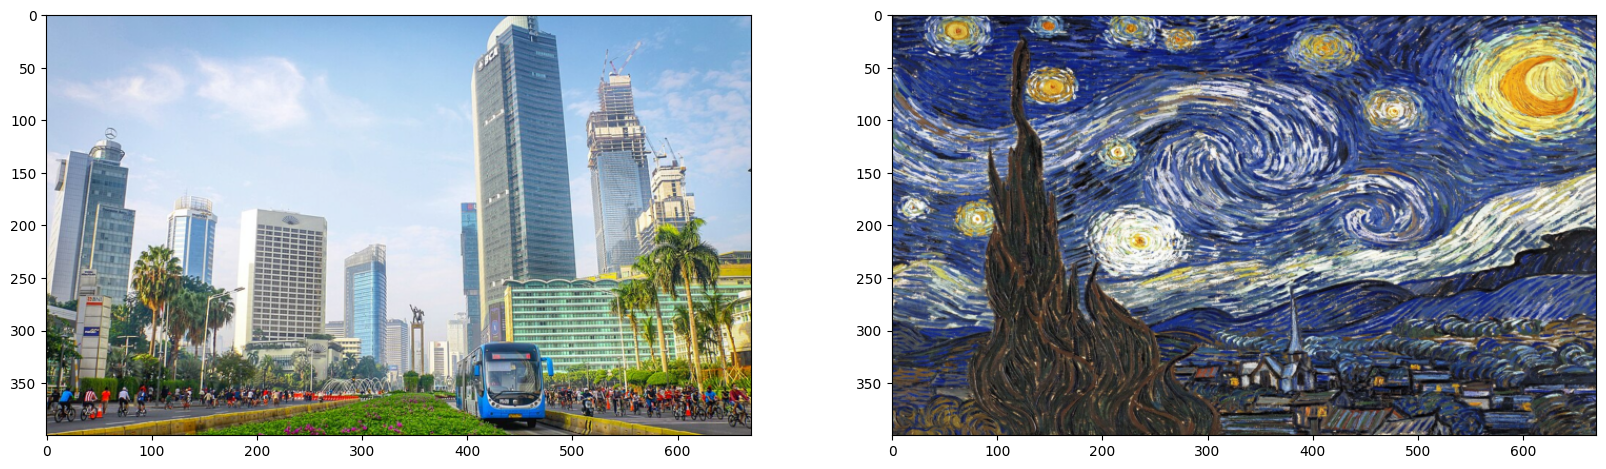

In [5]:
content = load_image('./image.jpg').to(device)
# Resize style to match content, makes code easier
style = load_image('./style.jpg', shape=content.shape[-2:]).to(device)

# helper function for un-normalizing an image
# and converting it from a Tensor image to a NumPy image for display
def im_convert(tensor):
    """ Display a tensor as an image. """

    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze()
    image = image.transpose(1,2,0)
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))
    image = image.clip(0, 1)

    return image
# display the images
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
# content and style ims side-by-side
ax1.imshow(im_convert(content))
ax2.imshow(im_convert(style))

In [6]:
def get_features(image, model, layers=None):
    """ Run an image forward through a model and get the features for
        a set of layers. Default layers are for VGGNet matching Gatys et al (2016)
    """

    if layers is None:
        layers = {'0': 'conv1_1',
                 '5':  'conv2_1',
                 '10': 'conv3_1',
                 '19': 'conv4_1',
                 '21': 'conv4_2',
                 '28': 'conv5_1'}

    features = {}
    x = image
    # model._modules is a dictionary holding each module in the model
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x

    return features


def gram_matrix(tensor):
    """ Calculate the Gram Matrix of a given tensor
        Gram Matrix: https://en.wikipedia.org/wiki/Gramian_matrix
    """

    gram = None
    b, d, h, w = tensor.size()
    tensor = tensor.view(d, h*w)
    gram = torch.mm(tensor, tensor.t())
    return gram

In [7]:
# get content and style features only once before forming the target image
content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

# calculate the gram matrices for each layer of our style representation
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

# create a third "target" image and prep it for change
# it is a good idea to start of with the target as a copy of our *content* image
# then iteratively change its style
target = content.clone().requires_grad_(True).to(device)

CPU times: user 2min 41s, sys: 2min 14s, total: 4min 56s
Wall time: 4min 59s


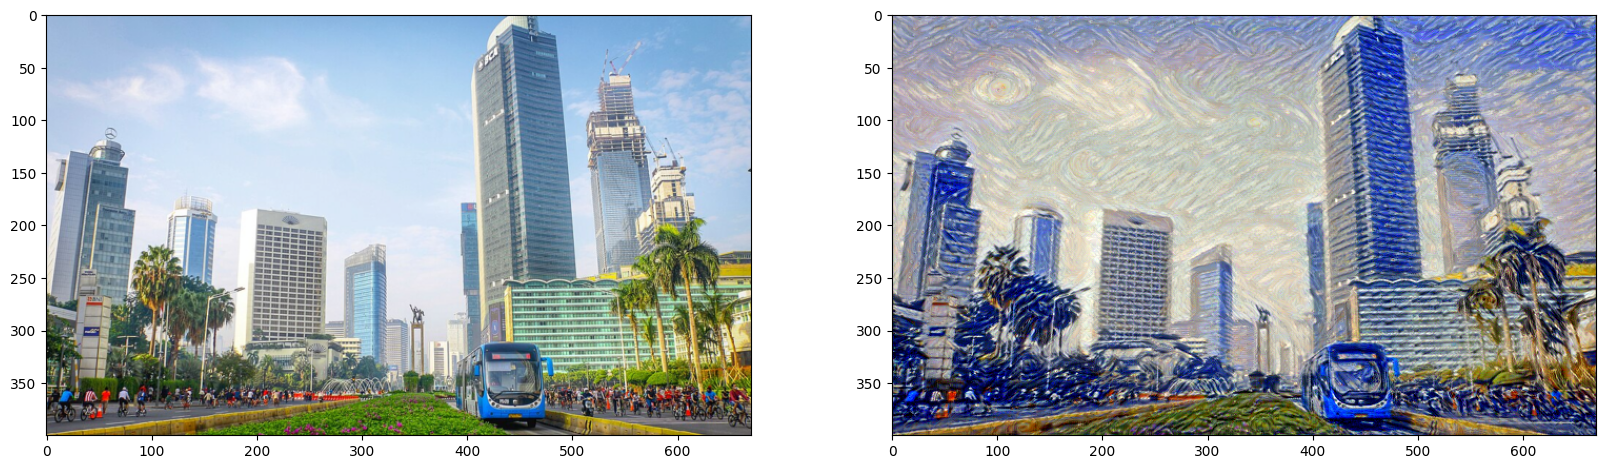

In [ ]:
%%time
# weights for each style layer
# weighting earlier layers more will result in *larger* style artifacts
# notice we are excluding `conv4_2` our content representation

style_weights = {'conv1_1': 1.,
'conv2_1': 0.8,
'conv3_1': 0.5,
'conv4_1': 0.3,
'conv5_1': 0.1}

content_weight = 1 # alpha
style_weight = 1e6 # beta

# iteration hyperparameters
optimizer = optim.Adam([target], lr=0.003)
steps = 3000  # decide how many iterations to update your image (5000)

for ii in range(1, steps+1):

    ## Then calculate the content loss
    target_features = get_features(target, vgg)
    content_loss = torch.mean((target_features["conv4_2"] - content_features["conv4_2"]) ** 2)

    # the style loss
    # initialize the style loss to 0
    style_loss = 0
    # iterate through each style layer and add to the style loss
    for layer in style_weights:
        # get the "target" style representation for the layer
        target_feature = target_features[layer]
        _, d, h, w = target_feature.shape
        target_gram = gram_matrix(target_feature)
        style_gram = style_grams[layer]
        layer_style_loss = style_weights[layer] * torch.mean((target_gram - style_gram) ** 2)

        # add to the style loss
        style_loss += layer_style_loss / (d * h * w)

    total_loss = content_weight * content_loss + style_weight * style_loss

    # update your target image
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

# display content and final, target image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.imshow(im_convert(content))
ax2.imshow(im_convert(target))

## Summary: Neural Style Transfer

### What We've Learned:

#### **Core Concepts**
- **CNN Feature Hierarchy**: Different layers capture different types of information
- **Content vs Style**: Content preserved through deep features, style through Gram matrices
- **Optimization Process**: Direct pixel optimization using pre-trained VGG features

#### **Key Components**
1. **VGG Feature Extractor**: Pre-trained network for feature extraction
2. **Content Loss**: MSE between deep layer features (conv4_2)
3. **Style Loss**: MSE between Gram matrices from multiple layers
4. **Total Variation Loss**: Spatial smoothness regularization

#### **Mathematical Foundation**
```
Total Loss = α × Content Loss + β × Style Loss + γ × TV Loss

Content Loss = ||F_l(G) - F_l(C)||²
Style Loss = Σ_l ||Gram(F_l(G)) - Gram(F_l(S))||²
TV Loss = Σ(|∇_x G| + |∇_y G|)
```

#### **Advantages**
- **High Quality**: Produces artistic and visually appealing results
- **Interpretable**: Clear separation of content and style
- **Flexible**: Can work with any style image
- **Well-understood**: Extensive research and analysis

#### **Limitations**
- **Slow**: Requires optimization for each image pair
- **Single Style**: Limited to transferring one style at a time
- **Resolution**: Computational cost increases with image size
- **Parameter Tuning**: Requires careful weight balancing

### **Modern Developments**

Since the original paper, many improvements have been proposed:

1. **Fast Style Transfer**: Feed-forward networks for real-time processing
2. **AdaIN (Adaptive Instance Normalization)**: More flexible style control
3. **Neural Doodle**: Semantic style transfer with spatial control
4. **Photorealistic Style Transfer**: Preserving photorealism
5. **Video Style Transfer**: Temporal consistency for videos

### **Applications**

- **Digital Art**: Creating artistic renditions of photographs
- **Content Creation**: Stylized images for media and marketing
- **Photo Enhancement**: Artistic filters and effects
- **Research**: Understanding CNN representations
- **Mobile Apps**: Real-time style transfer on devices

### **Key Takeaways**

1. **Pre-trained Features**: Leveraging existing CNN knowledge is powerful
2. **Multi-scale Style**: Using multiple layers captures style at different scales
3. **Gram Matrices**: Effective way to capture texture and style patterns
4. **Optimization**: Direct image optimization works well for this task
5. **Trade-offs**: Quality vs speed considerations in practical applications